In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

data_dir = "Logs/CSVLogger"
subdir_name = "version_"
df = []
for i in os.listdir(data_dir):
    if i.startswith(subdir_name):
        df.append(pd.read_csv(f"{data_dir}/{i}/metrics.csv"))

df = pd.concat(df, axis = 0)

In [2]:
df_means = df.groupby("epoch").mean()
df_stds = df.groupby("epoch").std()

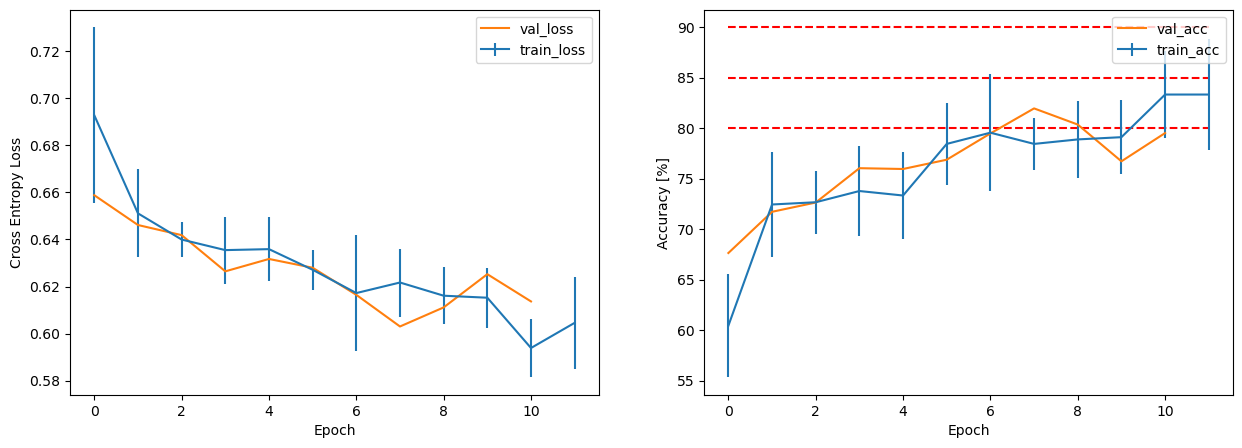

Current epoch (starting from 000): 11
Lowest val loss: 0.6030282378196716
Corresponding accuracy: 81.9600%
Epochs since last val loss improvement: 4


In [3]:
fig = plt.figure(figsize = (15, 5))
ax = fig.add_subplot(1, 2, 1)
ax.errorbar(x = list(df_means.index), y = df_means.train_loss, yerr = df_stds.train_loss, label = "train_loss")
ax.plot(list(df_means.index), df_means.val_loss, label = "val_loss")
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross Entropy Loss")

ax = fig.add_subplot(1, 2, 2)
ax.hlines(xmin = np.min(list(df_means.index)), xmax = np.max(list(df_means.index)), y = 80, color = "red", linestyle = "--")
ax.hlines(xmin = np.min(list(df_means.index)), xmax = np.max(list(df_means.index)), y = 85, color = "red", linestyle = "--")
ax.hlines(xmin = np.min(list(df_means.index)), xmax = np.max(list(df_means.index)), y = 90, color = "red", linestyle = "--")
ax.errorbar(x = list(df_means.index), y = df_means.train_acc*100, yerr = df_stds.train_acc*100, label = "train_acc")
ax.plot(list(df_means.index), df_means.val_acc*100, label = "val_acc")

ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy [%]")

plt.show()

lowest_val_loss = np.min(df_means.val_loss)
lowest_val_loss_index = np.argmin(df_means.val_loss)
acc_of_best_loss = df_means.val_acc.iloc[lowest_val_loss_index]
current_val_loss_index = df_means.shape[0] - 1
difference_index = current_val_loss_index - lowest_val_loss_index
print(f"Current epoch (starting from 000): {current_val_loss_index}")
print(f"Lowest val loss: {lowest_val_loss}")
print(f"Corresponding accuracy: {acc_of_best_loss:.4%}")
print(f"Epochs since last val loss improvement: {difference_index}")

In [4]:
# idee: nach 5 epochen lr senken